# Lesson 9 — Segmentatsiya Amaliyoti

Ushbu notebook semantic, instance va panoptic segmentatsiya turlarini YOLO modellari yordamida amaliy tarzda o'rganish uchun mo'ljallangan.

**Talab qilinadigan kutubxonalar:** `ultralytics`, `matplotlib`, `pillow`, `torch` (oldindan o'rnatilgan bo'lishi kerak)



## Task 1 — Semantic Segmentation 

### Maqsad

Model rasmda **har bir pikselga class belgisi** beradi. Instancelarni ajratmaydi — barcha odamlar bir xil rang, barcha mashinalar bir xil rang bilan belgilanadi.

### Loss Funksiyalari

- **Cross-Entropy Loss**: `L = -sum(y * log(p))` — har bir piksel uchun class classification xatoligini hisoblaydi.
- **Dice Loss**: `L = 1 - (2*|A∩B|) / (|A|+|B|)` — class nomuvozanati (class imbalance) bo'lganda ishlatiladi, kichik obyektlarni yaxshiroq aniqlash uchun foydali.

### Baholash Metrikalari

- **mIoU (Mean Intersection over Union)**: asosiy metrika, qiymati 0 dan 1 gacha, yuqori bo'lsa — natija yaxshi.
- **Pixel Accuracy**: to'g'ri bashorat qilingan piksellar sonining jami piksellar soniga nisbati.


image 1/1 c:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\-------------github---.webp: 448x640 1 person, 1 cup, 1 chair, 2 keyboards, 1023.2ms
Speed: 3.3ms preprocess, 1023.2ms inference, 8.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\runs\segment\predict-4


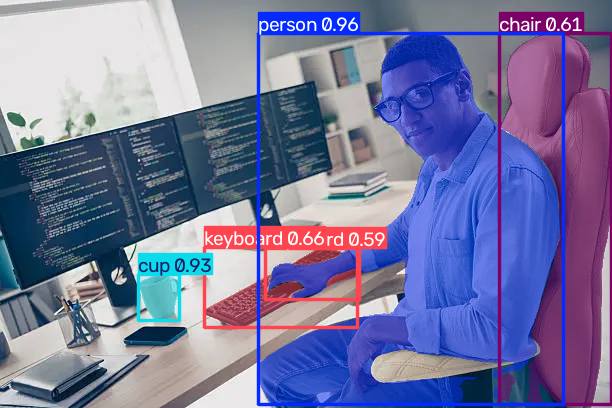

In [5]:
# Load a pretrained YOLO segmentation model and run prediction
from ultralytics import YOLO
from PIL import Image

model = YOLO('yolo26l-seg.pt')

# Run prediction on a sample image
results = model.predict(
    source='https://media.istockphoto.com/id/2216315630/ko/%EC%82%AC%EC%A7%84/%EC%A0%8A%EC%9D%80-%EB%82%A8%EC%9E%90%EC%9D%98-%EC%82%AC%EC%A7%84-%EC%9E%90%EC%98%81%EC%97%85-%EB%82%B4%EC%84%B1%EC%A0%81-%EC%9D%B8-%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%A8%B8%EB%8A%94-%EC%82%AC%EB%AC%B4%EC%8B%A4-%EB%B0%B0%EA%B2%BD%EC%97%90%EC%84%9C-%EC%9D%B8%ED%84%B0%EB%84%B7-%EC%BD%94%EB%8D%94%EB%A5%BC-%EC%9C%84%ED%95%9C-%ED%94%84%EB%A6%AC%EB%9E%9C%EC%8A%A4-github-%EC%9B%B9%EC%82%AC%EC%9D%B4%ED%8A%B8%EC%97%90%EC%84%9C-%EC%9D%BC%ED%95%98%EA%B3%A0-%EC%9E%88%EC%8A%B5%EB%8B%88%EB%8B%A4.webp?a=1&b=1&s=612x612&w=0&k=20&c=th54_JThk6VWHmTK0IOs_lJQ_N6KOWEpq1b-75QbSkQ=',
    conf=0.45,
    save=True
)

# Display the segmented image
for r in results:
    display(Image.fromarray(r.plot()[..., ::-1]))


0: 640x640 1 person, 1 cup, 1460.7ms
1: 640x640 7 persons, 1460.7ms
2: 640x640 1 handbag, 1 chair, 2 tvs, 1 mouse, 1 keyboard, 1460.7ms
Speed: 5.0ms preprocess, 1460.7ms inference, 13.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\runs\segment\predict-6


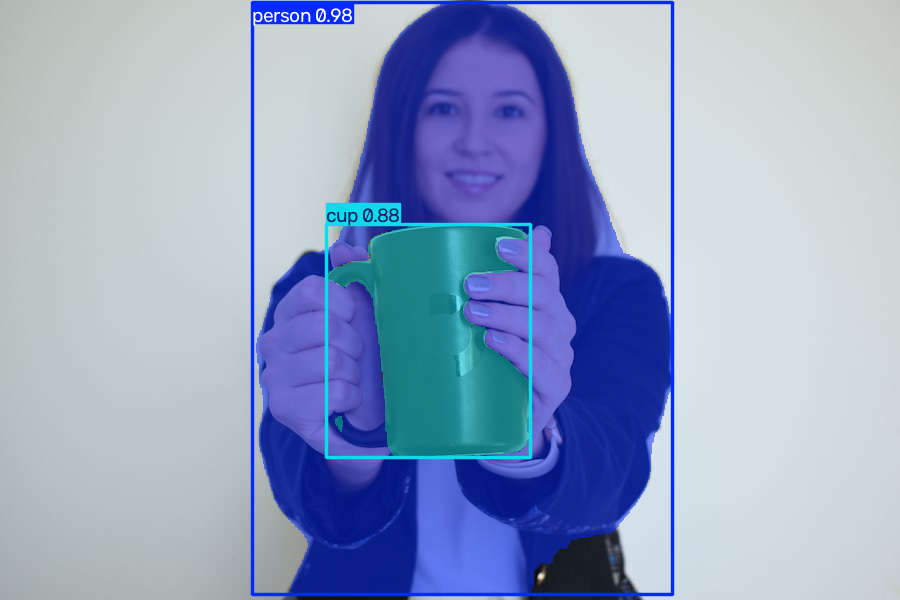

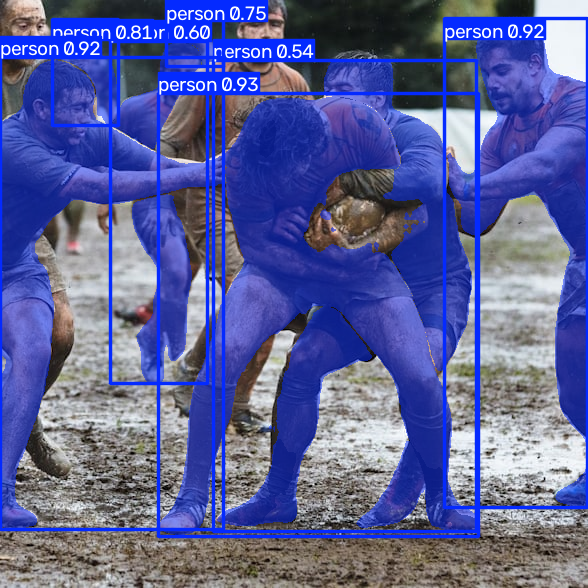

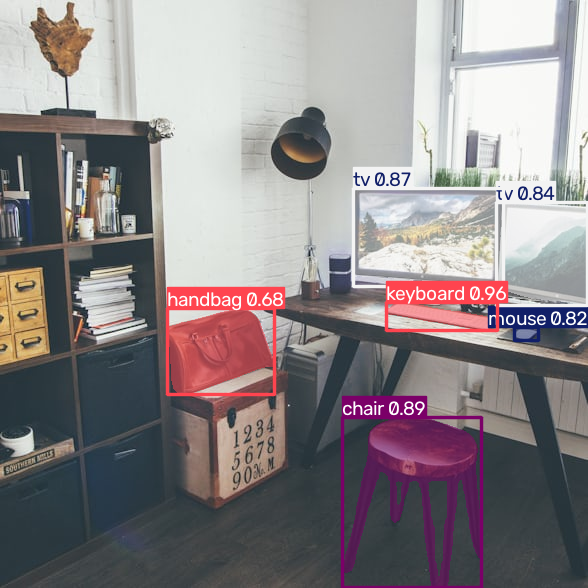

In [7]:
model = YOLO('yolo26l-seg.pt')

# Run prediction on 3 sample images
results = model.predict(
    source=[
        'https://images.unsplash.com/photo-1664194493125-4d1fe78a037d?w=900&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MzZ8fGdpdGh1YnxlbnwwfHwwfHx8MA%3D%3D',
        'https://images.unsplash.com/photo-1508057187925-17094f679b10?w=294&dpr=2&h=294&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxjb2xsZWN0aW9uLXRodW1ibmFpbHx8ODgzMTc4OHx8ZW58MHx8fHx8',
        'https://images.unsplash.com/photo-1496664444929-8c75efb9546f?w=294&dpr=2&h=294&auto=format&fit=crop&q=60&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxjb2xsZWN0aW9uLXRodW1ibmFpbHx8OTY3MTg2fHxlbnwwfHx8fHw%3D'  # replace with your own image path/URL
    ],
    conf=0.45,
    save=True
)

# Display the segmented images
for r in results:
    display(Image.fromarray(r.plot()[..., ::-1]))

In [8]:
import yaml
from pathlib import Path
import ultralytics
from ultralytics import YOLO, settings
from ultralytics.utils.downloads import download

# 1. Writable datasets directory
datasets_dir = Path.cwd() / "datasets"
datasets_dir.mkdir(parents=True, exist_ok=True)
settings.update({"datasets_dir": str(datasets_dir)})

# 2. Download & extract coco128-seg if not already there
coco_dir = datasets_dir / "coco128-seg"
if not coco_dir.exists():
    download("https://ultralytics.com/assets/coco128-seg.zip", dir=datasets_dir, unzip=True, delete=True)

# 3. Take the original coco128-seg.yaml shipped with ultralytics and fix the 'path'
src_yaml = Path(ultralytics.__file__).parent / "cfg" / "datasets" / "coco128-seg.yaml"

# FIX 1: Explicitly added encoding="utf-8" to read the file correctly
cfg = yaml.safe_load(src_yaml.read_text(encoding="utf-8"))
cfg["path"] = str(coco_dir)

dst_yaml = datasets_dir / "coco128-seg.yaml"

# FIX 2: Explicitly added encoding="utf-8" when writing the file to prevent future errors
dst_yaml.write_text(yaml.dump(cfg, sort_keys=False), encoding="utf-8")

# 4. Validate using the fixed yaml
metrics = model.val(data=str(dst_yaml), verbose=False)

print(f"Box  mAP50-95 : {metrics.box.map:.4f}")
print(f"Mask mAP50-95 : {metrics.seg.map:.4f}")
print(f"Mask mAP50    : {metrics.seg.map50:.4f}")


Unzipping c:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\datasets\coco128-seg.zip to C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\datasets\coco128-seg...: 100% ━━━━━━━━━━━━ 263/263 439.4files/s 0.6s0.1s
Ultralytics 8.4.96  Python-3.11.9 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-1355U)
WARNING val: Slow image access detected (ping: 0.10.1 ms, read: 3.43.0 MB/s, size: 50.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\datasets\coco128-seg\labels\train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 37.5it/s 3.4s0.0ss
val: New cache created: C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\datasets\coco128-seg\labels\train2017.cache
                 Class     Images  Instances      Box(P          R      mAP

### Mulohaza uchun savol

Rasmda nechta odam bor? Model ularni alohida ko'rsatyaptimi? Semantic segmentation nima uchun ularni bir-biridan ajrata olmaydi?

## Task 2 — Instance Segmentation 

### Maqsad

Har bir ob'ekt **o'z alohida maskasiga** ega bo'ladi. Bir xil classdagi turli ob'ektlar ham bir-biridan ajratiladi — masalan, Car #1, Car #2 kabi alohida instance sifatida.

### Loss Funksiyalari

- **Cross-Entropy Loss**: classification uchun — ob'ekt qaysi classga tegishli ekanini aniqlaydi.
- **Binary Mask Loss**: `L = -[y*log(p) + (1-y)*log(1-p)]` — har bir instance uchun alohida binary mask xatoligini hisoblaydi.
- **Bounding Box Loss (CIoU)**: box koordinatalarining to'g'riligini o'lchaydi.

> **Eslatma:** Instance segmentation uchta loss yig'indisini optimallaydi: `cls + box + mask`.

### Baholash Metrikalari

- **mAP_box (mAP50-95)**: bounding box aniqligini ko'rsatadi.
- **mAP_mask (mAP50-95)**: pixel-level mask aniqligi — bu **asosiy metrika**.

> **Eslatma:** `mAP_box` har doim `mAP_mask` dan yuqori bo'ladi, chunki mask aniqroq (pixel darajasida) talabni bildiradi.


image 1/1 c:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\01.jpg: 448x640 4 persons, 6 wine glasss, 1 bowl, 2 dining tables, 368.2ms
Speed: 2.8ms preprocess, 368.2ms inference, 27.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\runs\segment\predict-9
Topildi: 13 ob'ekt
  [0] person — conf: 0.93
  [1] person — conf: 0.92
  [2] person — conf: 0.91
  [3] wine glass — conf: 0.87
  [4] wine glass — conf: 0.78
  [5] wine glass — conf: 0.69
  [6] person — conf: 0.68
  [7] wine glass — conf: 0.68
  [8] wine glass — conf: 0.51
  [9] dining table — conf: 0.49
  [10] wine glass — conf: 0.45
  [11] dining table — conf: 0.45
  [12] bowl — conf: 0.25
Mask shape: torch.Size([13, 446, 668])  (N, H, W)


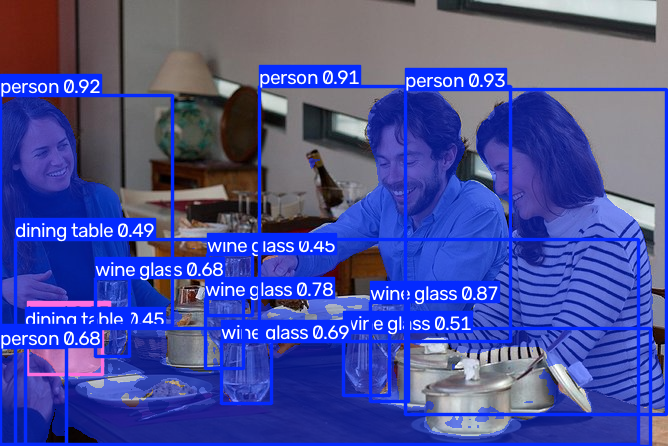

In [16]:
# Run instance segmentation prediction with retina masks for higher mask quality
from ultralytics import YOLO
from PIL import Image

model = YOLO('yolo26n-seg.pt')

results = model.predict(
    source='https://media.tacdn.com/media/attractions-splice-spp-674x446/0a/90/c5/01.jpg',
    conf=0.25,
    retina_masks=True,
    save=True
)

# Print detected instances with class names and confidence scores
for r in results:
    print(f"Topildi: {len(r.boxes)} ob'ekt")
    for i, box in enumerate(r.boxes):
        cls_name = model.names[int(box.cls)]
        confidence = float(box.conf)
        print(f"  [{i}] {cls_name} — conf: {confidence:.2f}")
    if r.masks is not None:
        print(f"Mask shape: {r.masks.data.shape}  (N, H, W)")
    display(Image.fromarray(r.plot()[..., ::-1]))

In [17]:
import yaml
from pathlib import Path
import ultralytics
from ultralytics import YOLO, settings
from ultralytics.utils.downloads import download

# 1. Setup a safe, writable datasets directory inside your current working folder
datasets_dir = Path.cwd() / "datasets"
datasets_dir.mkdir(parents=True, exist_ok=True)
settings.update({"datasets_dir": str(datasets_dir)})

# 2. Download and extract the data locally if it's missing
coco_dir = datasets_dir / "coco128-seg"
if not coco_dir.exists():
    download("https://ultralytics.com", dir=datasets_dir, unzip=True, delete=True)

# 3. Load the default config template with explicit UTF-8 decoding for Windows
src_yaml = Path(ultralytics.__file__).parent / "cfg" / "datasets" / "coco128-seg.yaml"
cfg = yaml.safe_load(src_yaml.read_text(encoding="utf-8"))

# 4. Point the configuration data path directly to your safe local folder
cfg["path"] = str(coco_dir)
dst_yaml = datasets_dir / "coco128-seg.yaml"
dst_yaml.write_text(yaml.dump(cfg, sort_keys=False), encoding="utf-8")

# 5. Validate the model using your newly fixed yaml path
metrics = model.val(data=str(dst_yaml), verbose=False)

# Print out your comparison metrics
print(f"Box  mAP50-95 : {metrics.box.map:.4f}")
print(f"Box  mAP50    : {metrics.box.map50:.4f}")
print(f"Mask mAP50-95 : {metrics.seg.map:.4f}")
print(f"Mask mAP50    : {metrics.seg.map50:.4f}")

print(f"\nmAP_box > mAP_mask: {metrics.box.map:.4f} > {metrics.seg.map:.4f}")


Ultralytics 8.4.96  Python-3.11.9 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-1355U)
WARNING val: Slow image access detected (ping: 0.90.1 ms, read: 20.013.7 MB/s, size: 46.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\datasets\coco128-seg\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 8.1s/it 1:055.0s8s
                   all        128        929      0.645      0.591      0.644      0.479       0.64      0.573      0.612      0.409
Speed: 1.2ms preprocess, 403.2ms inference, 0.0ms loss, 34.3ms postprocess per image
Results saved to C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 

### Mulohaza uchun savol

Task 1 bilan farqi ko'rinyaptimi? Har bir odam o'z rangiga egami? `Mask shape`dagi `N` qiymati nimani anglatadi?

## Task 3 — Panoptic Side-by-side Taqqoslash 

### Maqsad

Uchala turni bir ekranda ko'rib, farqni o'z ko'zingiz bilan qiyoslang. **Panoptic = Semantic + Instance**. *Things* (sanab bo'ladigan ob'ektlar) va *Stuff* (fon hududlari) birlashtirilgan holda ko'rsatiladi.

### Loss Funksiyalari

- **Panoptic loss** = Semantic loss + Instance loss birlashmasi.
- **Stuff loss (Cross-Entropy)**: osmon, yo'l kabi fon (background) hududlari uchun.
- **Things loss (Binary Mask + BBox + CE)**: sanab bo'ladigan ob'ektlar uchun.

**Final formula:**

`L_panoptic = L_stuff + L_things` (ikkalasi parallel ravishda optimallashadi)

### Baholash Metrikalari

- **PQ (Panoptic Quality)** = `SQ × RQ` — asosiy metrika.
- **SQ (Segmentation Quality)** = mos kelgan segmentlarning o'rtacha IoU qiymati — mask chegarasi aniqligini ko'rsatadi.
- **RQ (Recognition Quality)** = `TP / (TP + 0.5*FP + 0.5*FN)` — ob'ektni to'g'ri topish darajasi.
- **PQ_Things**: faqat sanab bo'ladigan ob'ektlar uchun hisoblanadi.
- **PQ_Stuff**: faqat fon hududlari uchun hisoblanadi.

Found https://photos.smugmug.com/Events-1/Alumni-Events/Family-Weekend-2018/i-qqFbKnZ/0/e0b6e603/L/181109502-L.jpg locally at 181109502-L.jpg
Found https://photos.smugmug.com/Events-1/Alumni-Events/Family-Weekend-2018/i-qqFbKnZ/0/e0b6e603/L/181109502-L.jpg locally at 181109502-L.jpg
Found https://photos.smugmug.com/Events-1/Alumni-Events/Family-Weekend-2018/i-qqFbKnZ/0/e0b6e603/L/181109502-L.jpg locally at 181109502-L.jpg
Rasm saqlandi: taqqoslash.png


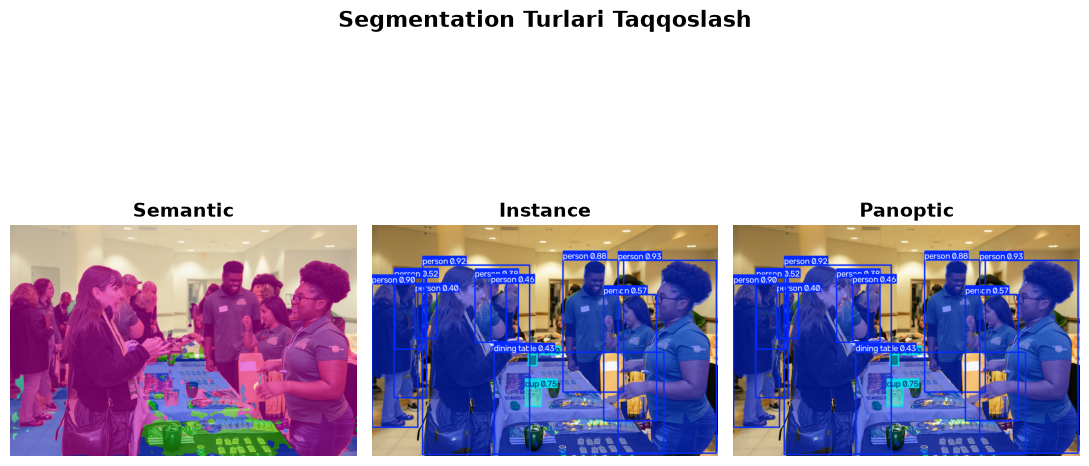

In [ ]:
# Compare Semantic, Instance and Panoptic-style outputs side by side
# %matplotlib inline
import matplotlib.pyplot as plt
from ultralytics import YOLO

IMAGE = 'https://photos.smugmug.com/Events-1/Alumni-Events/Family-Weekend-2018/i-qqFbKnZ/0/e0b6e603/L/181109502-L.jpg'

model = YOLO('yolo26n-sem.pt')

# Load models for each segmentation style
sem  = YOLO('yolo26n-sem.pt')
inst = YOLO('yolo26n-seg.pt')
pan  = YOLO('yolo26n-seg.pt')

# Run predictions
r_sem  = sem.predict(IMAGE,  conf=0.25, verbose=False)
r_inst = inst.predict(IMAGE, conf=0.25, retina_masks=True, verbose=False)
r_pan  = pan.predict(IMAGE,  conf=0.25, verbose=False)

# Plot all three results side by side
fig, axes = plt.subplots(1, 3, figsize=(11, 6))
for ax, res, title in zip(
        axes,
        [r_sem, r_inst, r_pan],
        ['Semantic', 'Instance', 'Panoptic']):
    ax.imshow(res[0].plot()[..., ::-1])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Segmentation Turlari Taqqoslash', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('taqqoslash.png', dpi=150, bbox_inches='tight')
print("Rasm saqlandi: taqqoslash.png")
plt.show()


In [29]:
# Print detailed per-instance results from the panoptic-style model
print("=== Panoptic natijalar ===")
for r in r_pan:
    if r.masks is not None:
        for i, (box, mask) in enumerate(zip(r.boxes, r.masks)):
            cls_name = pan.names[int(box.cls)]
            conf = float(box.conf)
            print(f"  [{i}] {cls_name}  conf={conf:.2f}  mask_shape={mask.data.shape}")

=== Panoptic natijalar ===
  [0] person  conf=0.93  mask_shape=torch.Size([1, 448, 640])
  [1] person  conf=0.92  mask_shape=torch.Size([1, 448, 640])
  [2] person  conf=0.90  mask_shape=torch.Size([1, 448, 640])
  [3] person  conf=0.88  mask_shape=torch.Size([1, 448, 640])
  [4] cup  conf=0.75  mask_shape=torch.Size([1, 448, 640])
  [5] person  conf=0.57  mask_shape=torch.Size([1, 448, 640])
  [6] person  conf=0.52  mask_shape=torch.Size([1, 448, 640])
  [7] person  conf=0.46  mask_shape=torch.Size([1, 448, 640])
  [8] dining table  conf=0.43  mask_shape=torch.Size([1, 448, 640])
  [9] person  conf=0.40  mask_shape=torch.Size([1, 448, 640])
  [10] cup  conf=0.40  mask_shape=torch.Size([1, 448, 640])
  [11] person  conf=0.38  mask_shape=torch.Size([1, 448, 640])
  [12] person  conf=0.38  mask_shape=torch.Size([1, 448, 640])


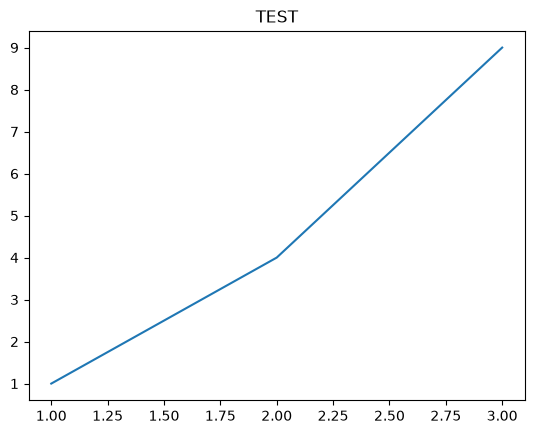

In [32]:
%matplotlib inline

import matplotlib.pyplot as plt
from IPython.display import display

fig, ax = plt.subplots()

ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title("TEST")

display(fig)
plt.close(fig)

In [34]:
%pip install -U transformers timm safetensors


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------- ----------------- 6.8/12.1 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 30.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 27.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 21.8 MB/s  0:00:00

   ---------------------------------------- 0/5 [safetensors]
  Attempting uninstall: regex
   ---------------------------------------- 0/5 [safetensors]
    Found existing installation: regex 2025.9.18
   ---------------------------------------- 0/5 [safetensors]
   -------- ------------------------------- 1/5 [regex]
    Uninstalling regex-2025.9.18:
   -------- ------------------------------- 1/5 [regex]
      Successfully uninstalled regex-2025.9.18
   -------- ------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\xolmu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Found https://photos.smugmug.com/Events-1/Alumni-Events/Family-Weekend-2018/i-qqFbKnZ/0/e0b6e603/L/181109502-L.jpg locally at 181109502-L.jpg
Found https://photos.smugmug.com/Events-1/Alumni-Events/Family-Weekend-2018/i-qqFbKnZ/0/e0b6e603/L/181109502-L.jpg locally at 181109502-L.jpg


preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

C:\Users\xolmu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\xolmu\.cache\huggingface\hub\models--facebook--mask2former-swin-tiny-coco-panoptic. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/82.2k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/190M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/554 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-panoptic
Key                                                                                                                                | Status     | 
-----------------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0, 1, 2, 3, 4, 5}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                             | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were n

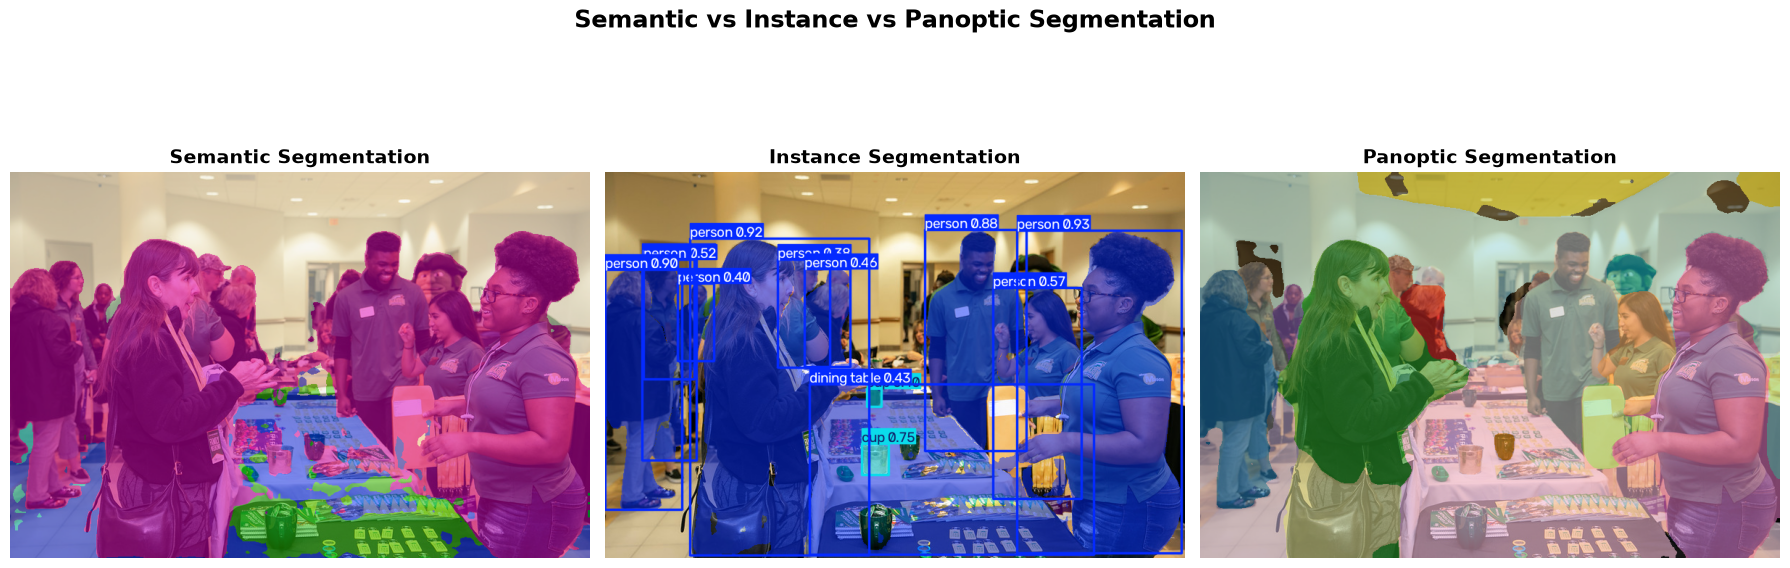

Rasm saqlandi: segmentation_comparison.png


In [35]:
import io
import requests
import numpy as np
import matplotlib.pyplot as plt
import torch

from PIL import Image
from IPython.display import display
from ultralytics import YOLO
from transformers import (
    AutoImageProcessor,
    Mask2FormerForUniversalSegmentation
)


# ============================================================
# 1. IMAGE
# ============================================================

IMAGE = (
    "https://photos.smugmug.com/Events-1/Alumni-Events/"
    "Family-Weekend-2018/i-qqFbKnZ/0/e0b6e603/L/181109502-L.jpg"
)


# URL rasmini PIL formatida yuklash
response = requests.get(IMAGE, timeout=30)
response.raise_for_status()

pil_image = Image.open(
    io.BytesIO(response.content)
).convert("RGB")


# ============================================================
# 2. SEMANTIC SEGMENTATION
# ============================================================

sem_model = YOLO("yolo26n-sem.pt")

r_sem = sem_model.predict(
    IMAGE,
    conf=0.25,
    verbose=False
)

# YOLO plot BGR formatda qaytarishi mumkin,
# shuning uchun RGB ga aylantiramiz
semantic_image = r_sem[0].plot()[..., ::-1]


# ============================================================
# 3. INSTANCE SEGMENTATION
# ============================================================

inst_model = YOLO("yolo26n-seg.pt")

r_inst = inst_model.predict(
    IMAGE,
    conf=0.25,
    retina_masks=True,
    verbose=False
)

instance_image = r_inst[0].plot()[..., ::-1]


# ============================================================
# 4. PANOPTIC SEGMENTATION
# ============================================================

PANOPTIC_MODEL = "facebook/mask2former-swin-tiny-coco-panoptic"

processor = AutoImageProcessor.from_pretrained(
    PANOPTIC_MODEL
)

pan_model = Mask2FormerForUniversalSegmentation.from_pretrained(
    PANOPTIC_MODEL
)


# GPU bo'lsa GPU, bo'lmasa CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

pan_model = pan_model.to(device)
pan_model.eval()


# Rasmni modelga tayyorlash
inputs = processor(
    images=pil_image,
    return_tensors="pt"
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}


# Prediction
with torch.no_grad():
    outputs = pan_model(**inputs)


# Panoptic post-processing
pan_result = processor.post_process_panoptic_segmentation(
    outputs,
    target_sizes=[
        (pil_image.height, pil_image.width)
    ]
)[0]


# H x W segment ID map
panoptic_map = (
    pan_result["segmentation"]
    .cpu()
    .numpy()
)

segments_info = pan_result["segments_info"]


# ============================================================
# 5. PANOPTIC MAPNI RANGLI RASMGA AYLANTIRISH
# ============================================================

original = np.array(pil_image)

panoptic_color = np.zeros_like(
    original,
    dtype=np.uint8
)

# Segmentlar soniga qarab colormap
num_segments = max(
    len(segments_info),
    1
)

cmap = plt.get_cmap(
    "tab20",
    num_segments
)


for i, segment in enumerate(segments_info):

    segment_id = segment["id"]

    mask = panoptic_map == segment_id

    rgb = np.array(
        cmap(i)[:3]
    ) * 255

    panoptic_color[mask] = rgb.astype(
        np.uint8
    )


# Original rasm + segmentation overlay
panoptic_image = (
    0.45 * original +
    0.55 * panoptic_color
).astype(np.uint8)


# ============================================================
# 6. UCHALASINI YONMA-YON KO'RSATISH
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)


# Semantic
axes[0].imshow(
    semantic_image
)

axes[0].set_title(
    "Semantic Segmentation",
    fontsize=14,
    fontweight="bold"
)

axes[0].axis("off")


# Instance
axes[1].imshow(
    instance_image
)

axes[1].set_title(
    "Instance Segmentation",
    fontsize=14,
    fontweight="bold"
)

axes[1].axis("off")


# Panoptic
axes[2].imshow(
    panoptic_image
)

axes[2].set_title(
    "Panoptic Segmentation",
    fontsize=14,
    fontweight="bold"
)

axes[2].axis("off")


plt.suptitle(
    "Semantic vs Instance vs Panoptic Segmentation",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()


# Saqlash
plt.savefig(
    "segmentation_comparison.png",
    dpi=150,
    bbox_inches="tight"
)


# VS Code Jupyter'da majburiy render
display(fig)

plt.close(fig)

print(
    "Rasm saqlandi: segmentation_comparison.png"
)

## Task 4 — O'z rasmingiz bilan mustaqil ishlash (~15 daqiqa)

### Maqsad

Endi o'z rasmingizni tanlang. Internetdan yoki telefoningizdan **street, bozor, maktab, ko'cha** kabi joy rasmini toping va uni notebook joylashgan papkaga joylashtiring. Quyidagi koddagi `MY_IMAGE` o'zgaruvchisi qiymatini o'z fayl nomingiz bilan almashtiring.

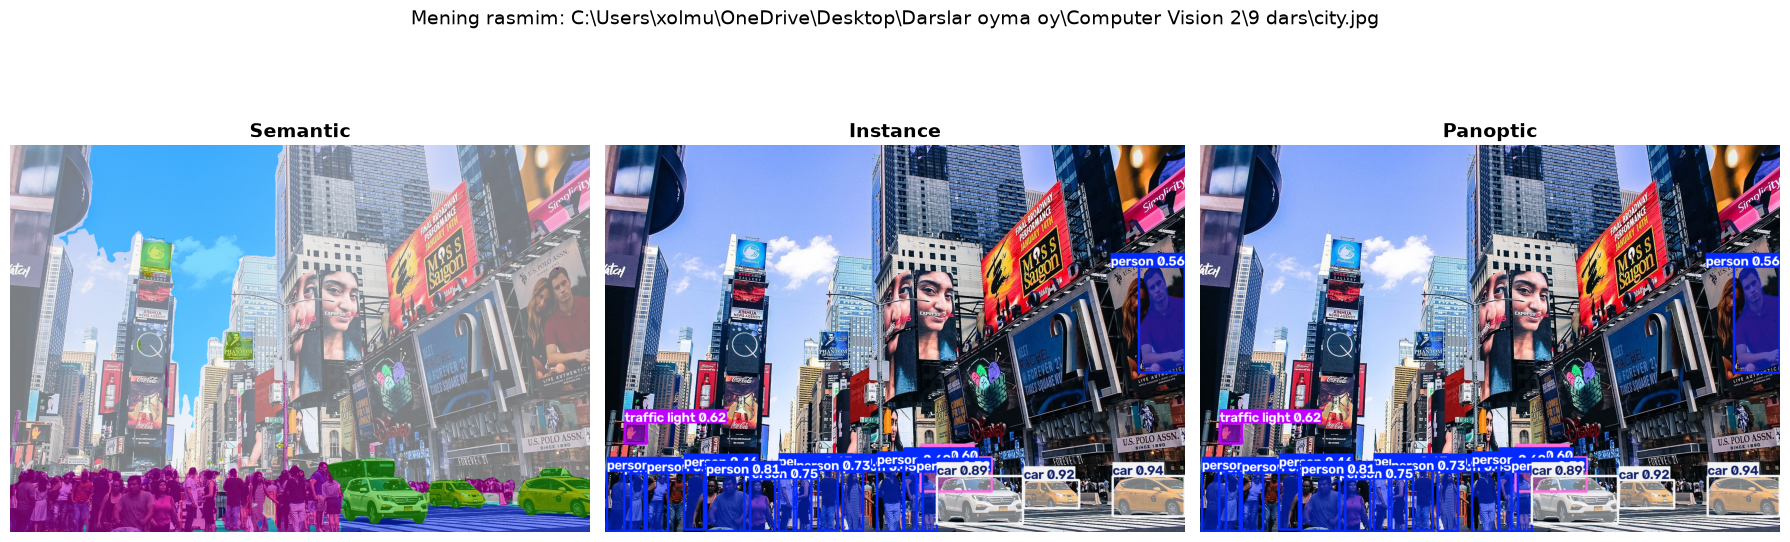

Instance soni: 19
  car — 0.94
  car — 0.92
  car — 0.89
  person — 0.81
  person — 0.75
  person — 0.73
  person — 0.72
  person — 0.69
  person — 0.67
  person — 0.65
  traffic light — 0.62
  person — 0.60
  person — 0.56
  person — 0.46
  person — 0.45
  bus — 0.43
  person — 0.41
  person — 0.40
  person — 0.38


In [36]:
# Run all three segmentation styles on your own image
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

MY_IMAGE = r'C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\city.jpg'  # <-- shu yerga o'z rasm yo'lingizni yozing

sem  = YOLO('yolo26m-sem.pt')
inst = YOLO('yolo26m-seg.pt')
pan  = YOLO('yolo26m-seg.pt')

r_sem  = sem.predict(MY_IMAGE,  conf=0.25, verbose=False)
r_inst = inst.predict(MY_IMAGE, conf=0.25, retina_masks=True, verbose=False)
r_pan  = pan.predict(MY_IMAGE,  conf=0.25, verbose=False)

# Plot the three results side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, res, title in zip(
        axes,
        [r_sem, r_inst, r_pan],
        ['Semantic', 'Instance', 'Panoptic']):
    ax.imshow(res[0].plot()[..., ::-1])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle(f"Mening rasmim: {MY_IMAGE}", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('mening_taqqoslashim.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detected instances
print(f"Instance soni: {len(r_inst[0].boxes)}")
for box in r_inst[0].boxes:
    print(f"  {inst.names[int(box.cls)]} — {float(box.conf):.2f}")

Loading weights:   0%|          | 0/554 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-panoptic
Key                                                                                                                                | Status     | 
-----------------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0, 1, 2, 3, 4, 5}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                             | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were n

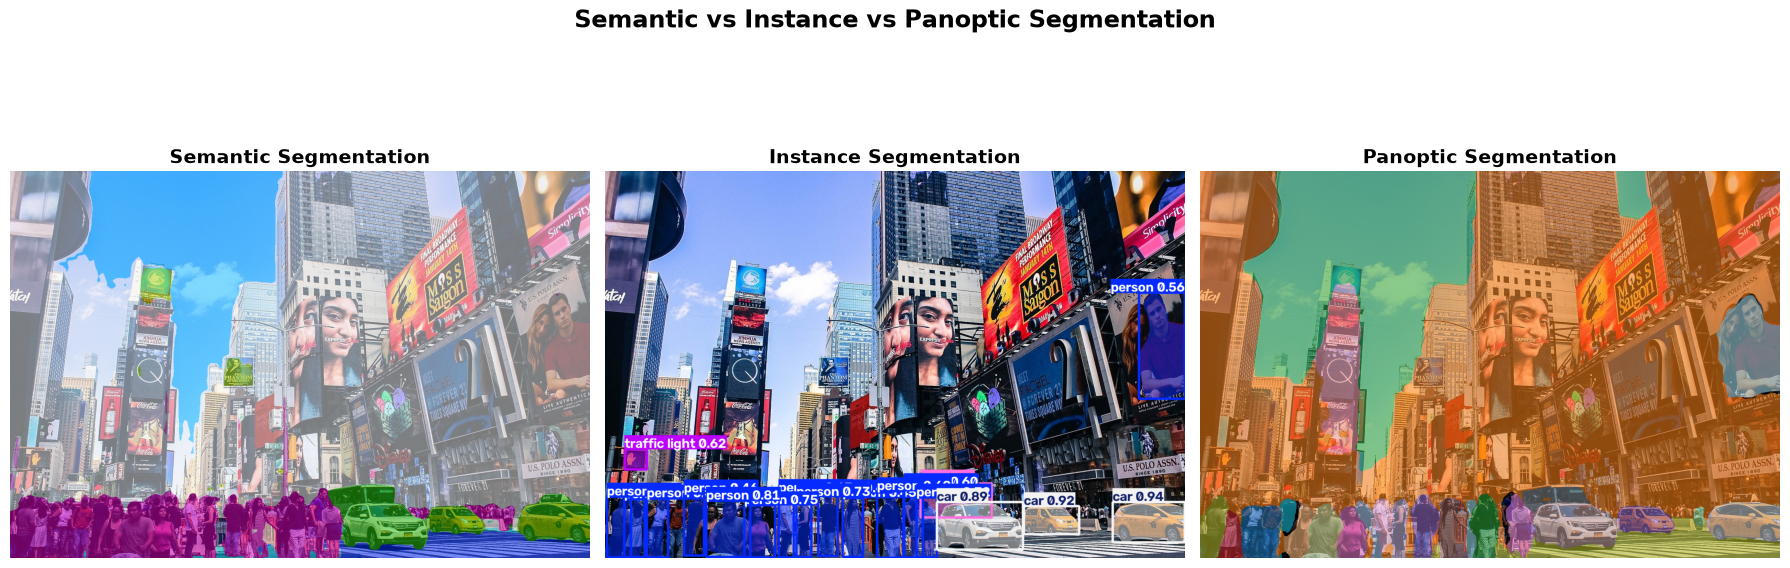


========== INSTANCE ==========
Instance soni: 19
car — 0.94
car — 0.92
car — 0.89
person — 0.81
person — 0.75
person — 0.73
person — 0.72
person — 0.69
person — 0.67
person — 0.65
traffic light — 0.62
person — 0.60
person — 0.56
person — 0.46
person — 0.45
bus — 0.43
person — 0.41
person — 0.40
person — 0.38

========== PANOPTIC ==========
Segmentlar soni: 26
Segment ID: 1 | Class ID: 0 | Class: person | Score: 0.86
Segment ID: 2 | Class ID: 0 | Class: person | Score: 0.93
Segment ID: 3 | Class ID: 0 | Class: person | Score: 0.80
Segment ID: 4 | Class ID: 129 | Class: building-other-merged | Score: 0.98
Segment ID: 5 | Class ID: 0 | Class: person | Score: 0.91
Segment ID: 6 | Class ID: 0 | Class: person | Score: 0.99
Segment ID: 7 | Class ID: 119 | Class: sky-other-merged | Score: 1.00
Segment ID: 8 | Class ID: 0 | Class: person | Score: 0.53
Segment ID: 9 | Class ID: 0 | Class: person | Score: 0.87
Segment ID: 10 | Class ID: 80 | Class: banner | Score: 0.60
Segment ID: 11 | Class ID:

In [37]:
# ============================================================
# Semantic + Instance + Panoptic Segmentation taqqoslash
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from ultralytics import YOLO

from transformers import (
    AutoImageProcessor,
    Mask2FormerForUniversalSegmentation
)


# ============================================================
# 1. O'Z RASMIMIZ YO'LI
# ============================================================

MY_IMAGE = r"C:\Users\xolmu\OneDrive\Desktop\Darslar oyma oy\Computer Vision 2\9 dars\city.jpg"


# ============================================================
# 2. RASMNI OCHISH
# ============================================================

pil_image = Image.open(MY_IMAGE).convert("RGB")
original = np.array(pil_image)


# ============================================================
# 3. SEMANTIC SEGMENTATION
# ============================================================

# -sem.pt = Semantic Segmentation
sem = YOLO("yolo26m-sem.pt")

r_sem = sem.predict(
    MY_IMAGE,
    conf=0.25,
    verbose=False
)

# YOLO plot natijasini RGB ga o'tkazamiz
semantic_image = r_sem[0].plot()[..., ::-1]


# ============================================================
# 4. INSTANCE SEGMENTATION
# ============================================================

# -seg.pt = Instance Segmentation
inst = YOLO("yolo26m-seg.pt")

r_inst = inst.predict(
    MY_IMAGE,
    conf=0.25,
    retina_masks=True,
    verbose=False
)

instance_image = r_inst[0].plot()[..., ::-1]


# ============================================================
# 5. PANOPTIC SEGMENTATION
# ============================================================

# Haqiqiy Panoptic model
PANOPTIC_MODEL = "facebook/mask2former-swin-tiny-coco-panoptic"

processor = AutoImageProcessor.from_pretrained(
    PANOPTIC_MODEL
)

pan_model = Mask2FormerForUniversalSegmentation.from_pretrained(
    PANOPTIC_MODEL
)


# GPU bo'lsa GPU ishlatiladi, aks holda CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

pan_model = pan_model.to(device)
pan_model.eval()


# Rasmni Mask2Former formatiga tayyorlash
inputs = processor(
    images=pil_image,
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}


# Prediction
with torch.no_grad():
    outputs = pan_model(**inputs)


# Panoptic natijani original rasm o'lchamiga qaytarish
pan_result = processor.post_process_panoptic_segmentation(
    outputs,
    target_sizes=[
        (pil_image.height, pil_image.width)
    ]
)[0]


# Har bir pixel uchun Segment ID
panoptic_map = (
    pan_result["segmentation"]
    .cpu()
    .numpy()
)

# Har bir segment haqida ma'lumot
segments_info = pan_result["segments_info"]


# ============================================================
# 6. PANOPTIC MASKNI RANGLI QILISH
# ============================================================

panoptic_color = np.zeros_like(
    original,
    dtype=np.uint8
)

num_segments = max(
    len(segments_info),
    1
)

cmap = plt.get_cmap(
    "tab20",
    num_segments
)


for i, segment in enumerate(segments_info):

    segment_id = segment["id"]

    # Shu segmentga tegishli pixellar
    mask = panoptic_map == segment_id

    # Rang
    rgb = np.array(
        cmap(i)[:3]
    ) * 255

    panoptic_color[mask] = rgb.astype(
        np.uint8
    )


# Original rasm bilan maskni aralashtirish
panoptic_image = (
    0.45 * original +
    0.55 * panoptic_color
).astype(np.uint8)


# ============================================================
# 7. UCHALASINI YONMA-YON KO'RSATISH
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)


# Semantic
axes[0].imshow(
    semantic_image
)

axes[0].set_title(
    "Semantic Segmentation",
    fontsize=14,
    fontweight="bold"
)

axes[0].axis("off")


# Instance
axes[1].imshow(
    instance_image
)

axes[1].set_title(
    "Instance Segmentation",
    fontsize=14,
    fontweight="bold"
)

axes[1].axis("off")


# Panoptic
axes[2].imshow(
    panoptic_image
)

axes[2].set_title(
    "Panoptic Segmentation",
    fontsize=14,
    fontweight="bold"
)

axes[2].axis("off")


plt.suptitle(
    "Semantic vs Instance vs Panoptic Segmentation",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()


# ============================================================
# 8. RASMNI SAQLASH
# ============================================================

plt.savefig(
    "mening_taqqoslashim.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. INSTANCE NATIJALARINI CHIQARISH
# ============================================================

print("\n========== INSTANCE ==========")

print(
    f"Instance soni: {len(r_inst[0].boxes)}"
)

for box in r_inst[0].boxes:

    class_id = int(box.cls.item())

    confidence = float(
        box.conf.item()
    )

    class_name = inst.names[
        class_id
    ]

    print(
        f"{class_name} — {confidence:.2f}"
    )


# ============================================================
# 10. PANOPTIC SEGMENTLARNI CHIQARISH
# ============================================================

print("\n========== PANOPTIC ==========")

print(
    f"Segmentlar soni: {len(segments_info)}"
)

for segment in segments_info:

    segment_id = segment["id"]

    class_id = segment["label_id"]

    score = segment.get(
        "score",
        None
    )

    class_name = pan_model.config.id2label.get(
        class_id,
        str(class_id)
    )

    if score is not None:

        print(
            f"Segment ID: {segment_id} | "
            f"Class ID: {class_id} | "
            f"Class: {class_name} | "
            f"Score: {score:.2f}"
        )

    else:

        print(
            f"Segment ID: {segment_id} | "
            f"Class ID: {class_id} | "
            f"Class: {class_name}"
        )

## Xulosa

### Loss funksiyalari oilalari

| Segmentatsiya turi | Loss komponentlari | Formula |
|---|---|---|
| Semantic | Cross-Entropy, Dice | `L = -sum(y*log(p))`, `L = 1 - 2\|A∩B\|/(\|A\|+\|B\|)` |
| Instance | Cross-Entropy + Binary Mask + CIoU Box | `L = cls + box + mask` |
| Panoptic | Stuff loss (CE) + Things loss (mask+box+cls) | `L_panoptic = L_stuff + L_things` |

### Baholash metrikalari

| Metrika | Segmentatsiya turi | Tavsif |
|---|---|---|
| mIoU | Semantic | O'rtacha Intersection over Union, 0–1 oralig'ida |
| Pixel Accuracy | Semantic | To'g'ri piksellar / jami piksellar |
| mAP_box | Instance | Bounding box aniqligi (mAP50-95) |
| mAP_mask | Instance | Pixel mask aniqligi (asosiy metrika) |
| PQ | Panoptic | `SQ × RQ`, umumiy sifat ko'rsatkichi |
| SQ | Panoptic | Mos kelgan segmentlarning o'rtacha IoU'si |
| RQ | Panoptic | `TP / (TP + 0.5FP + 0.5FN)` — topish darajasi |

### Asosiy farqlar

- **Semantic**: faqat class darajasida ishlaydi, instancelarni ajratmaydi.
- **Instance**: har bir ob'ektni alohida ajratadi, lekin fon (background) hisobga olinmaydi.
- **Panoptic**: ikkalasini birlashtiradi — har bir piksel ham class, ham (agar 'thing' bo'lsa) instance ID oladi.